In [53]:
#Loading data
import numpy as np
import pandas as pd

In [54]:
df=pd.read_csv("/content/imdb_top_1000.csv")
df.head()
df.info()
df.describe()
df.isnull()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True


In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
#inspection
df.isnull().sum()

,0
Poster_Link,0
Series_Title,0
Released_Year,0
Certificate,101
Runtime,0
Genre,0
IMDB_Rating,0
Overview,0
Meta_score,157
Director,0


In [57]:
df[["Released_Year", "Gross"]].head(10)

,Released_Year,Gross
0,1994,"28,341,469"
1,1972,"134,966,411"
2,2008,"534,858,444"
3,1974,"57,300,000"
4,1957,"4,360,000"
5,2003,"377,845,905"
6,1994,"107,928,762"
7,1993,"96,898,818"
8,2010,"292,576,195"
9,1999,"37,030,102"


In [58]:
df["Gross"]=df["Gross"].str.replace(",","")
df["Gross"]=pd.to_numeric(df["Gross"])

In [59]:
df['Released_Year'].unique()

array(['1994', '1972', '2008', '1974', '1957', '2003', '1993', '2010',
       '1999', '2001', '1966', '2002', '1990', '1980', '1975', '2020',
       '2019', '2014', '1998', '1997', '1995', '1991', '1977', '1962',
       '1954', '1946', '2011', '2006', '2000', '1988', '1985', '1968',
       '1960', '1942', '1936', '1931', '2018', '2017', '2016', '2012',
       '2009', '2007', '1984', '1981', '1979', '1971', '1963', '1964',
       '1950', '1940', '2013', '2005', '2004', '1992', '1987', '1986',
       '1983', '1976', '1973', '1965', '1959', '1958', '1952', '1948',
       '1944', '1941', '1927', '1921', '2015', '1996', '1989', '1978',
       '1961', '1955', '1953', '1925', '1924', '1982', '1967', '1951',
       '1949', '1939', '1937', '1934', '1928', '1926', '1920', '1970',
       '1969', '1956', '1947', '1945', '1930', '1938', '1935', '1933',
       '1932', '1922', '1943', 'PG'], dtype=object)

In [60]:
df['Released_Year'].sort_values().tail()
df['Released_Year']=df['Released_Year'].replace("PG",np.nan)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  999 non-null    object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    float64
dtypes: float64(3), int64(1), object(12)
memory usage: 125.1+ KB


In [62]:
ratings=df["IMDB_Rating"]

print("Mean Rating", np.mean(ratings))
print("Median Rating", np.median(ratings))
print("Standard Deviation", np.std(ratings))

Mean Rating 7.949299999999999
Median Rating 7.9
Standard Deviation 0.27535342743463326


In [63]:
#Genre Anaysis
genre_rating=df.groupby("Genre")["IMDB_Rating"].mean().sort_values(ascending=False)
print(genre_rating)

Genre
Animation, Drama, War         8.50
Action, Sci-Fi                8.40
Drama, Musical                8.40
Drama, Mystery, War           8.35
Western                       8.35
                              ... 
Action, Adventure, Mystery    7.60
Action, Adventure, Family     7.60
Action, Adventure, Crime      7.60
Animation, Drama, Romance     7.60
Drama, War, Western           7.60
Name: IMDB_Rating, Length: 202, dtype: float64


In [64]:
#Director Analysis
director_rating=df.groupby("Director")["IMDB_Rating"].mean().sort_values(ascending=False)
print(director_rating)

Director
Frank Darabont        8.95
Lana Wachowski        8.70
Irvin Kershner        8.70
Masaki Kobayashi      8.60
Fernando Meirelles    8.60
                      ... 
Tom Tykwer            7.60
Bennett Miller        7.60
Blake Edwards         7.60
Aneesh Chaganty       7.60
Walter Hill           7.60
Name: IMDB_Rating, Length: 548, dtype: float64


In [65]:
#Year Analysis
year_rating=df.groupby("Released_Year")["IMDB_Rating"].mean().sort_index()
print(year_rating)

Released_Year
1920    8.100000
1921    8.300000
1922    7.900000
1924    8.200000
1925    8.100000
          ...   
2016    7.935714
2017    7.890909
2018    7.994737
2019    7.995652
2020    8.133333
Name: IMDB_Rating, Length: 99, dtype: float64


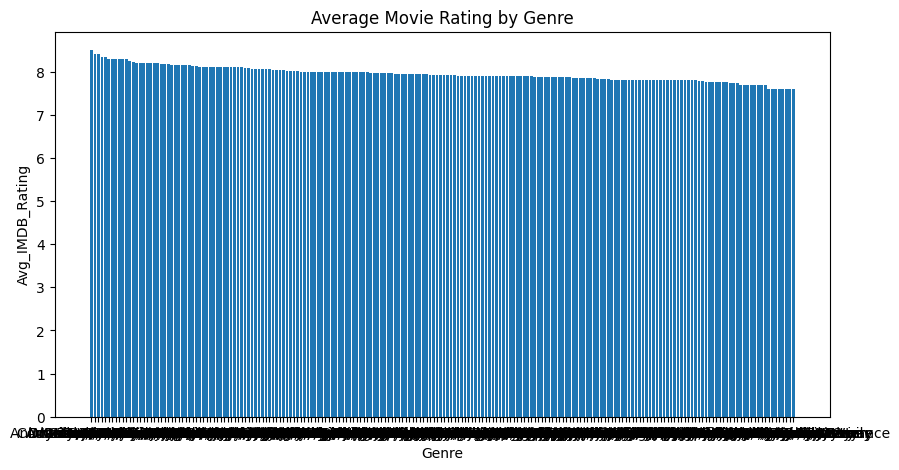

In [66]:
#Data Visualizations
import matplotlib.pyplot as plt

#Avg rating by genre
plt.figure(figsize=(10,5))
Avg_IMDB_Rating=np.mean(ratings)
plt.bar(
    genre_rating.index,
    genre_rating.values

)
plt.title("Average Movie Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Avg_IMDB_Rating")
plt.show()



In [67]:
avg_IMDB_Rating=np.mean(ratings)
print(avg_IMDB_Rating)

7.949299999999999


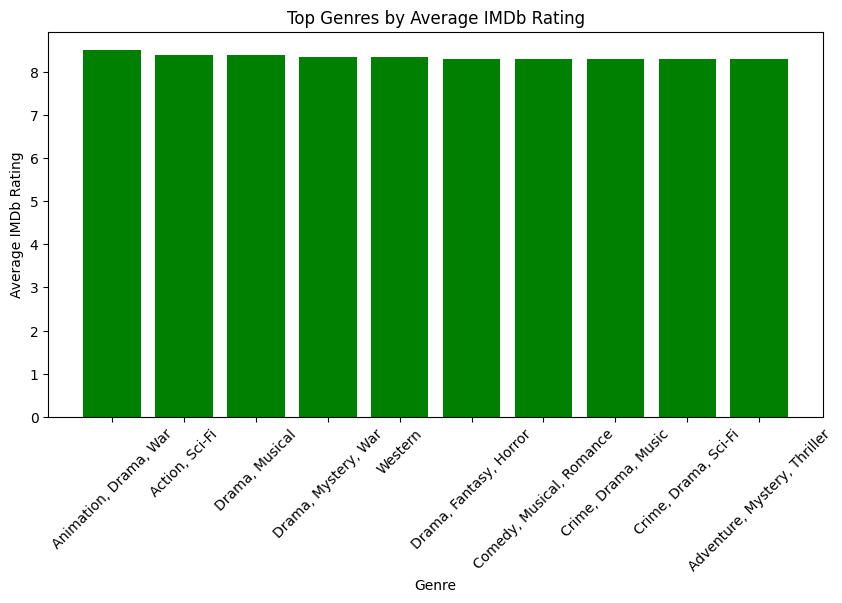

In [68]:
genre_rating = (
    df.groupby("Genre")["IMDB_Rating"]
    .mean()
    .sort_values(ascending=False)
)

# Take top 10 for readability
top_genres = genre_rating.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_genres.index,
    top_genres.values,
    color="green"
)

plt.title("Top Genres by Average IMDb Rating")
plt.xlabel("Genre")
plt.ylabel("Average IMDb Rating")

plt.xticks(rotation=45)

plt.show()

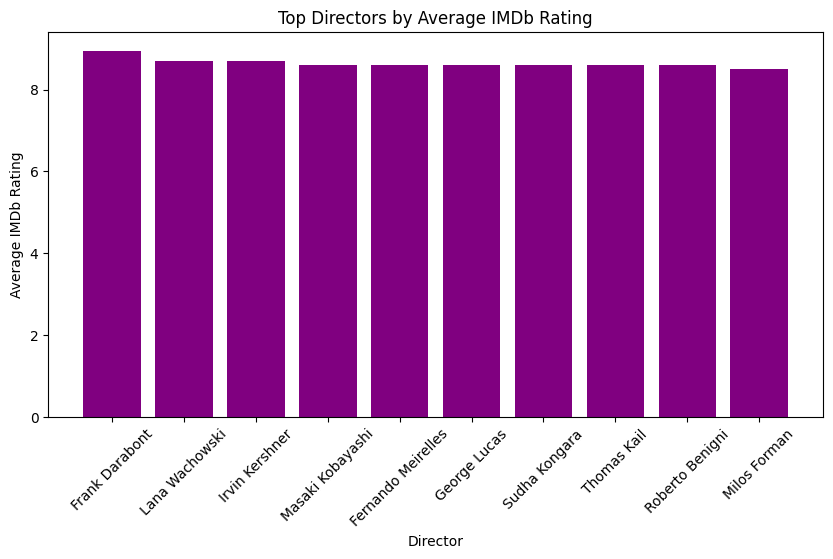

In [69]:
director_rating = (
    df.groupby("Director")["IMDB_Rating"]
    .mean()
    .sort_values(ascending=False)
)

top_directors = director_rating.head(10)


plt.figure(figsize=(10,5))

plt.bar(
    top_directors.index,
    top_directors.values,
    color="purple"
)

plt.title("Top Directors by Average IMDb Rating")
plt.xlabel("Director")
plt.ylabel("Average IMDb Rating")

plt.xticks(rotation=45)

plt.show()

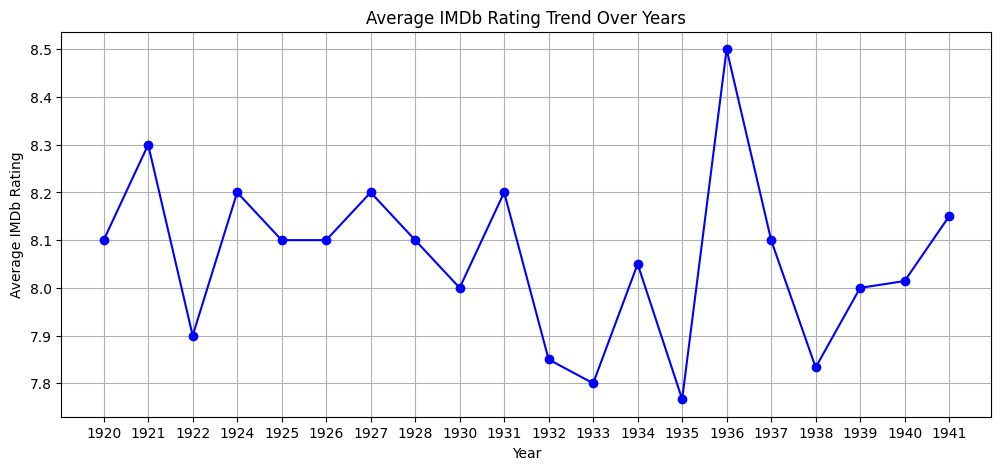

In [70]:
year_rating = (
    df.groupby("Released_Year")["IMDB_Rating"]
    .mean()
    .sort_index()
)

top_10_years = year_rating.head(20)

plt.figure(figsize=(12,5))

plt.plot(
    top_10_years.index,
    top_10_years.values,
    marker="o",
    color="blue"
)

plt.title("Average IMDb Rating Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average IMDb Rating")

plt.grid(True)

plt.show()

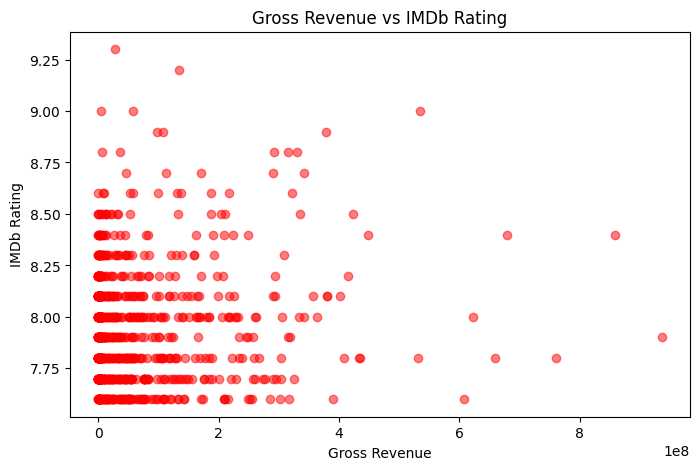

In [71]:
gross_df = df.dropna(subset=["Gross"])


plt.figure(figsize=(8,5))

plt.scatter(
    gross_df["Gross"],
    gross_df["IMDB_Rating"],
    alpha=0.5,
    color="red"
)

plt.title("Gross Revenue vs IMDb Rating")
plt.xlabel("Gross Revenue")
plt.ylabel("IMDb Rating")

plt.show()

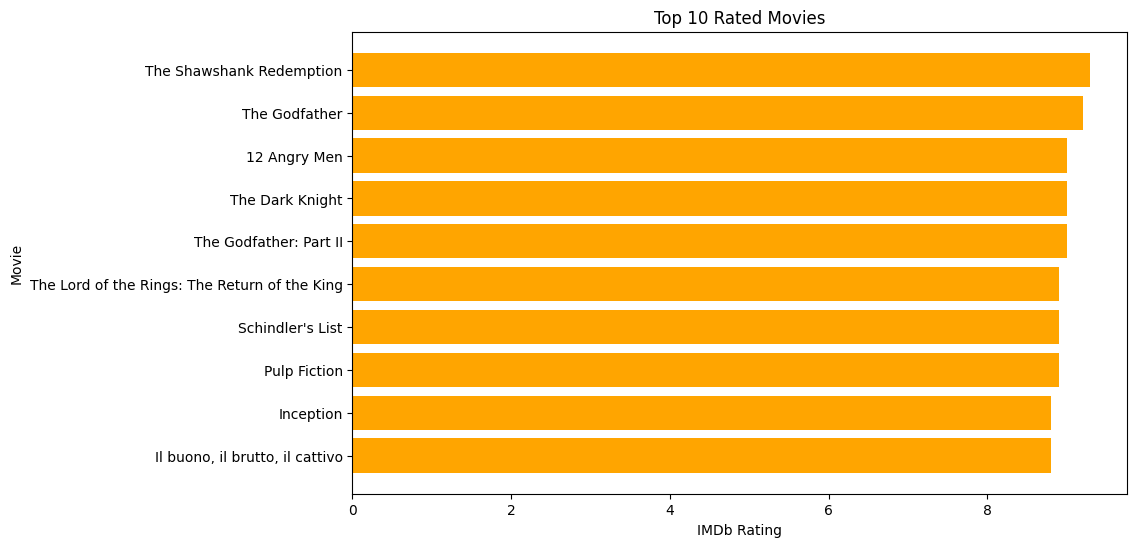

In [72]:
top_movies = (
    df[["Series_Title","IMDB_Rating"]]
    .sort_values(
        by="IMDB_Rating",
        ascending=False
    )
    .head(10)
)


plt.figure(figsize=(10,6))

plt.barh(
    top_movies["Series_Title"],
    top_movies["IMDB_Rating"],
    color="orange"
)

plt.xlabel("IMDb Rating")
plt.ylabel("Movie")

plt.title("Top 10 Rated Movies")

plt.gca().invert_yaxis()

plt.show()

In [73]:
#MOCK STARTED FROM HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

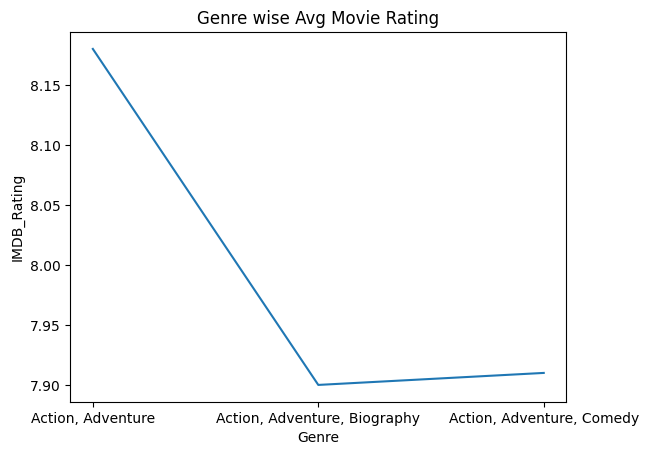

In [74]:
genre_rating= df.groupby("Genre")["IMDB_Rating"].mean().head(3)

plt.plot(
    genre_rating.index,
    genre_rating.values
)
plt.xlabel("Genre")
plt.ylabel("IMDB_Rating")
plt.title("Genre wise Avg Movie Rating")
plt.show()

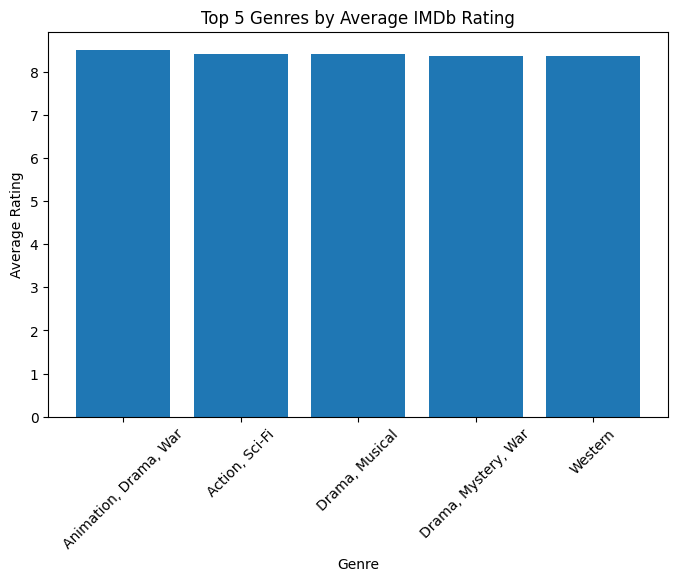

In [75]:
genre_rating = df.groupby("Genre")["IMDB_Rating"].mean().sort_values(ascending=False)

top5 = genre_rating.head(5)

plt.figure(figsize=(8,5))
plt.bar(top5.index, top5.values)
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.title("Top 5 Genres by Average IMDb Rating")
plt.xticks(rotation=45)
plt.show()



# plt.bar(df["Genre"], df["IMDB_Rating"])
# plt.xlabel("Genre")
# plt.ylabel("Rating")
# plt.title("Genre vs Rating")
# plt.show()

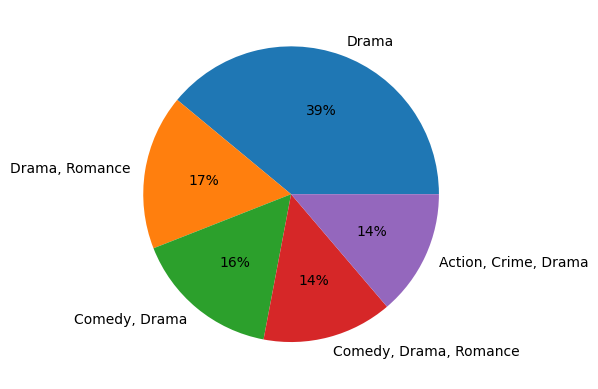

In [76]:
genre_rating=df['Genre'].value_counts().head()
plt.pie(
    genre_rating,
    labels=genre_rating.index,
    autopct="%1.f%%"
)
plt.show()

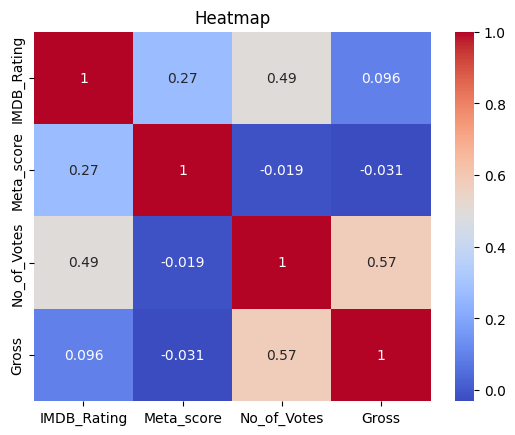

In [77]:
import seaborn as sns
#heatmap
numeric_df=df.select_dtypes(include="number")
corr=numeric_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Heatmap")
plt.show()

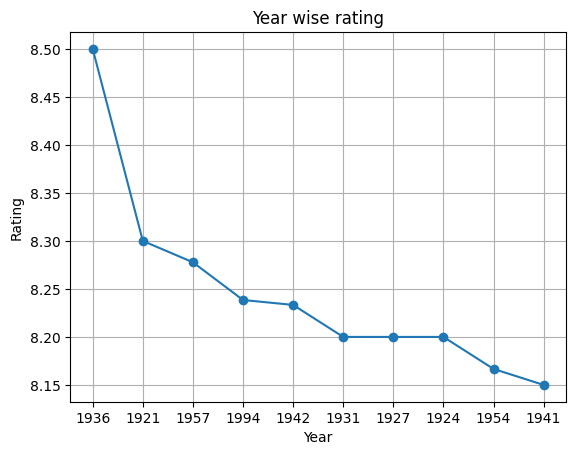

In [78]:
yearly_analsis=df.groupby("Released_Year")['IMDB_Rating'].mean().sort_values(ascending=False).head(10)
plt.plot(
    yearly_analsis.index,
    yearly_analsis.values,
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Rating")
plt.title("Year wise rating")
plt.grid(True)
plt.show()

In [79]:
import matplotlib.pyplot as plt



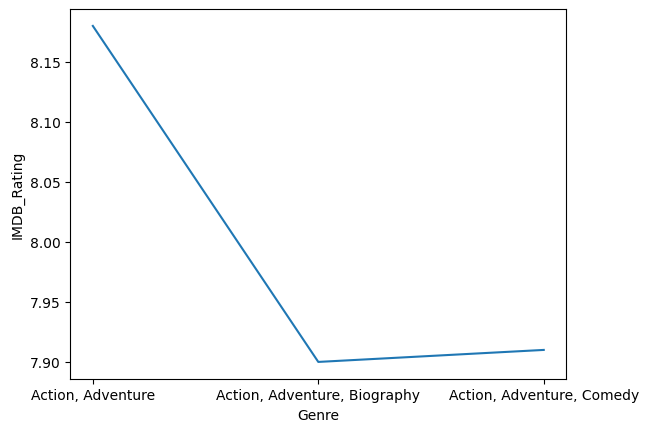

In [80]:
genre_rating=df.groupby("Genre")["IMDB_Rating"].mean().head(3)

plt.plot(
    genre_rating.index,
    genre_rating.values
)
plt.xlabel("Genre")
plt.ylabel("IMDB_Rating")
plt.show()